# Chapter 4 — Model-based RL
*Reinforcement Learning: An Overview*, Murphy (arXiv:2412.05265v5) — §4

Planning with known/learned models · Dyna-Q · MCTS · World models · Predictive representations

In [1]:
%pip install -q numpy matplotlib
print('ready')

/Users/ppcc/Desktop/Reinforcement-Learning/.venv/bin/python3: No module named pip


Note: you may need to restart the kernel to use updated packages.
ready


## 4.1 Dyna-Q: RL + Planning

After each real env step, do **n planning steps** using stored model $(s,a)\to(s',r)$.

More planning steps → better sample efficiency from real interactions.

Training Dyna-Q variants (0/5/50 planning steps)…


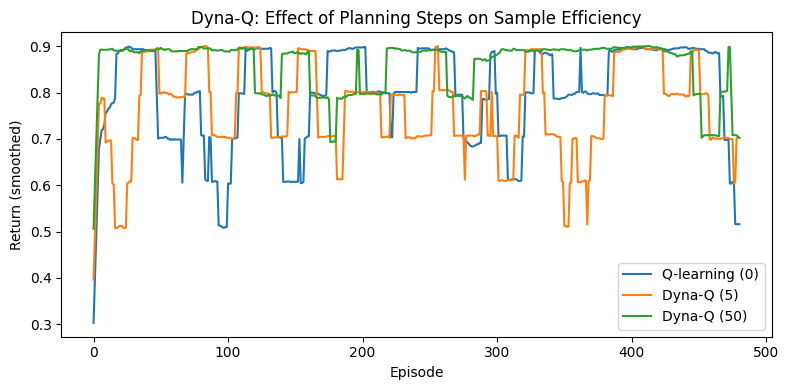

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class GridWorld:
    SIZE = 4; GOAL, HOLE = (3,3), (1,1)
    MOVES = [(-1,0),(1,0),(0,-1),(0,1)]
    def __init__(self, gamma=0.99): self.gamma=gamma; self.pos=(0,0)
    def reset(self): self.pos=(0,0); return self._i(self.pos)
    def step(self, a):
        r,c=self.pos; dr,dc=self.MOVES[a]
        self.pos=(max(0,min(3,r+dr)),max(0,min(3,c+dc)))
        if self.pos==self.GOAL: return self._i(self.pos), 1.0,True
        if self.pos==self.HOLE: return self._i(self.pos),-1.0,True
        return self._i(self.pos),-0.01,False
    def _i(self,pos): return pos[0]*4+pos[1]
    def pos_of(self,i): return (i//4,i%4)
    def n_states(self): return 16
    def n_actions(self): return 4

def dynaq(n_plan=10, n_ep=500, alpha=0.1, gamma=0.99, eps=0.1):
    env = GridWorld(gamma)
    S,A = env.n_states(), env.n_actions()
    Q = np.zeros((S,A)); model = {}; returns = []
    for _ in range(n_ep):
        s=env.reset(); G=0; gt=1
        for _ in range(200):
            a = np.random.randint(A) if np.random.rand()<eps else Q[s].argmax()
            ns,r,done = env.step(a)
            Q[s,a] += alpha*(r+gamma*Q[ns].max()-Q[s,a])
            model[(s,a)] = (ns,r); G+=gt*r; gt*=gamma
            for _ in range(n_plan):
                ps,pa = list(model)[np.random.randint(len(model))]
                pns,pr = model[(ps,pa)]
                Q[ps,pa] += alpha*(pr+gamma*Q[pns].max()-Q[ps,pa])
            s=ns
            if done: break
        returns.append(G)
    return returns

print("Training Dyna-Q variants (0/5/50 planning steps)…")
ret_0  = dynaq(n_plan=0)
ret_5  = dynaq(n_plan=5)
ret_50 = dynaq(n_plan=50)

smooth = lambda x,w=20: np.convolve(x,np.ones(w)/w,mode="valid")
plt.figure(figsize=(8,4))
for ret,lbl in [(ret_0,"Q-learning (0)"),(ret_5,"Dyna-Q (5)"),(ret_50,"Dyna-Q (50)")]:
    plt.plot(smooth(ret), label=lbl)
plt.xlabel("Episode"); plt.ylabel("Return (smoothed)")
plt.title("Dyna-Q: Effect of Planning Steps on Sample Efficiency")
plt.legend(); plt.tight_layout(); plt.show()


## 4.2 Monte Carlo Tree Search (MCTS)

Decision-time planning — four phases per simulation:
1. **Selection** — UCB1: $a^*=\arg\max_a\bigl[Q(s,a)+c\sqrt{\ln N(s)/N(s,a)}\bigr]$
2. **Expansion** — add unvisited child
3. **Simulation** — random rollout
4. **Backpropagation** — update $Q,N$ up the path

In [3]:
import numpy as np
import matplotlib.pyplot as plt

class GridWorld:
    SIZE = 4; GOAL, HOLE = (3,3), (1,1)
    MOVES = [(-1,0),(1,0),(0,-1),(0,1)]
    def __init__(self, gamma=0.99): self.gamma=gamma; self.pos=(0,0)
    def reset(self): self.pos=(0,0); return self._i(self.pos)
    def step(self, a):
        r,c=self.pos; dr,dc=self.MOVES[a]
        self.pos=(max(0,min(3,r+dr)),max(0,min(3,c+dc)))
        if self.pos==self.GOAL: return self._i(self.pos), 1.0,True
        if self.pos==self.HOLE: return self._i(self.pos),-1.0,True
        return self._i(self.pos),-0.01,False
    def _i(self,pos): return pos[0]*4+pos[1]
    def pos_of(self,i): return (i//4,i%4)
    def n_states(self): return 16
    def n_actions(self): return 4

class Node:
    __slots__ = ("state","pos","parent","children","N","Q")
    def __init__(self, state, pos, parent=None):
        self.state=state; self.pos=pos; self.parent=parent
        self.children={}; self.N=0; self.Q=0.0
    def ucb(self, c=1.41):
        if self.N==0: return float("inf")
        return self.Q/self.N + c*np.sqrt(np.log(self.parent.N)/self.N)


def mcts(start_pos=(0,0), n_sim=400, gamma=0.99):
    root = Node(0, start_pos)

    def rollout(pos):
        env=GridWorld(); env.pos=pos; G=0; gt=1
        for _ in range(50):
            _,r,done=env.step(np.random.randint(4)); G+=gt*r; gt*=gamma
            if done: break
        return G

    for _ in range(n_sim):
        node=root; env=GridWorld(); env.pos=start_pos; done=False
        # Selection
        while node.children and not done:
            a=max(node.children, key=lambda a: node.children[a].ucb())
            node=node.children[a]; _,_,done=env.step(a)
        # Expansion
        if not done:
            for a in range(4):
                if a not in node.children:
                    env2=GridWorld(); env2.pos=env.pos; env2.step(a)
                    node.children[a]=Node(env2._i(env2.pos), env2.pos, parent=node)
            a=np.random.choice(list(node.children))
            node=node.children[a]; env.pos=node.pos
        # Simulation + backprop
        G=rollout(env.pos)
        while node:
            node.N+=1; node.Q+=G; node=node.parent

    return max(root.children, key=lambda a: root.children[a].N if a in root.children else -1)

best = mcts()
print(f"MCTS from (0,0): action {best} = {['Up','Down','Left','Right'][best]}")
print("Optimal: Right or Down toward (3,3)")


MCTS from (0,0): action 1 = Down
Optimal: Right or Down toward (3,3)


## 4.3 World Models

Learn $\hat{p}(s'\mid s,a)$ and $\hat{r}(s,a)$ from data; plan inside the model.

Key challenge: **model errors compound** over planning horizon $h$:
$$\text{error}(h)=1-(1-\varepsilon)^h$$

Mitigation: short rollouts + value bootstrap (Dyna, Dreamer, MuZero).

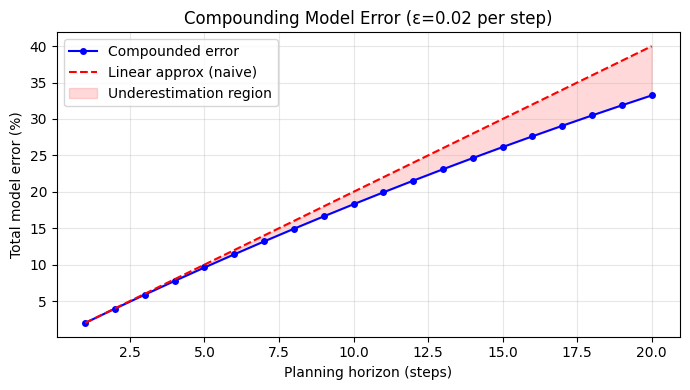

In [4]:
import numpy as np, matplotlib.pyplot as plt

h = np.arange(1, 21); eps = 0.02
plt.figure(figsize=(7,4))
plt.plot(h, (1-(1-eps)**h)*100, "b-o", ms=4, label="Compounded error")
plt.plot(h, eps*h*100, "r--", label="Linear approx (naive)")
plt.fill_between(h, (1-(1-eps)**h)*100, eps*h*100, alpha=0.15, color="red",
                 label="Underestimation region")
plt.xlabel("Planning horizon (steps)"); plt.ylabel("Total model error (%)")
plt.title(f"Compounding Model Error (ε={eps} per step)")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
